## Log Transformations


the shape of log curve shows that this transformation maps
- narrow range of low intensity values in the input into a wider range of output levels. 
- for example, note how input levels in the range `[0, L/4]` map to output levels to the range `[0, 3L/4]`.
- conversely, higher values of the input levels are mapped to a narrower range in the output.

<figure>
  <img src="Images/2_0_image.png" alt="log and inverse curves" width="350"/>
  <figcaption>log and inverse curves.</figcaption>
</figure>


we use a transformation of this type:
- to expand the values of dark pixels in an image.
- while compressing the higher-level values.

> the opposite is true of the inverse log (exponential) transformation.

the general form: 
$$ s = c\;log(1+r)$$

where: 
- r >= 0, and the `1` to avoid log(0) = inf
- For a digital image with intensity values ranging from `0` to `255` the transformation **log(r+1)** produces value in the range of `0` to `2.41`.
- **c** is a scaling constant.

Hence, a scaling operation is required to represent the logarithmically transformed intensity values in a bigger range. The scaling constant `c` does this.
$$ c =  \frac{255} {log(1+Maximum\;pixel\;value\;from\;the\;input\;image)} $$

In [46]:
import numpy as np

def log_transform(pixel_value: float, c: float) -> float:
    """
    Apply logarithmic transformation to a single pixel.
    
    Args:
        pixel_value: The original pixel intensity.
        c: Scaling constant.
    
    Returns:
        Transformed pixel intensity.
    """
    return c * np.log10(1 + pixel_value)


def log_transform_image(
    image: np.ndarray,
    c: float = 1.0,
    c_scaling: str = "Max",
    output_max: int = 255,
    input_max: int = 255,
    mode: str = "gray"
) -> np.ndarray:
    """
    Apply logarithmic transformation to an image (grayscale or RGB).

    Args:
        image: Input image as a numpy array.
        c: Scaling constant (ignored if c_scaling="Max").
        c_scaling: Method to compute scaling constant ("Max" or "Manual").
        output_max: Maximum intensity in the output image.
        input_max: Maximum intensity in the input image.
        mode: "gray" for grayscale or "rgb" for color images.

    Returns:
        Log-transformed image as a numpy array.
    """
    # Compute scaling constant if required
    if c_scaling == "Max":
        c = output_max / np.log10(1 + input_max)

    # Apply transformation
    if mode == "gray":
        # Ensure the image is float for calculation
        image_float = image.astype(float)
        transformed = np.round(log_transform(image_float, c)).astype(np.uint8)
    elif mode == "rgb":
        # Ensure the image is float for calculation
        image_float = image.astype(float)
        transformed = np.zeros_like(image, dtype=np.uint8)
        for channel in range(3):
            transformed[:, :, channel] = np.round(log_transform(image_float[:, :, channel], c))
    else:
        raise ValueError("Invalid mode. Use 'gray' or 'rgb'.")

    return transformed


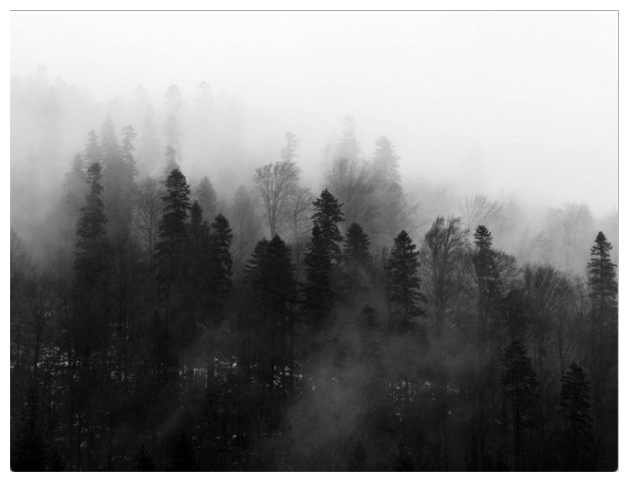

In [47]:
import cv2 
import matplotlib.pyplot as plt

image = cv2.imread('Images/2_1_image.png', cv2.IMREAD_GRAYSCALE)

plt.figure(figsize= (10,6))
plt.imshow(image, cmap = "gray")
plt.axis("off")
plt.show()

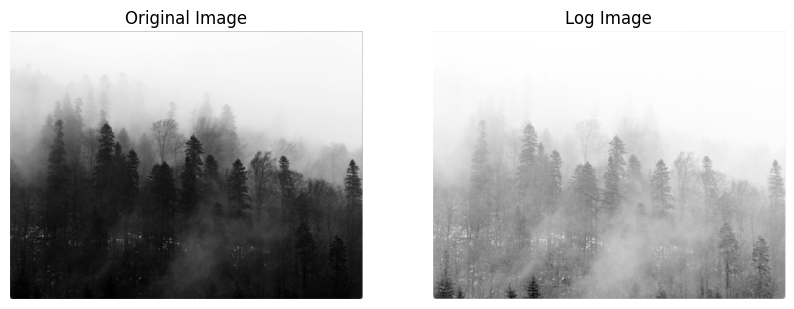

In [48]:
log_image = log_transform_image(image=image.copy())
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap="gray")
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(log_image, cmap="gray")
plt.title('Log Image')
plt.axis('off')

plt.show()

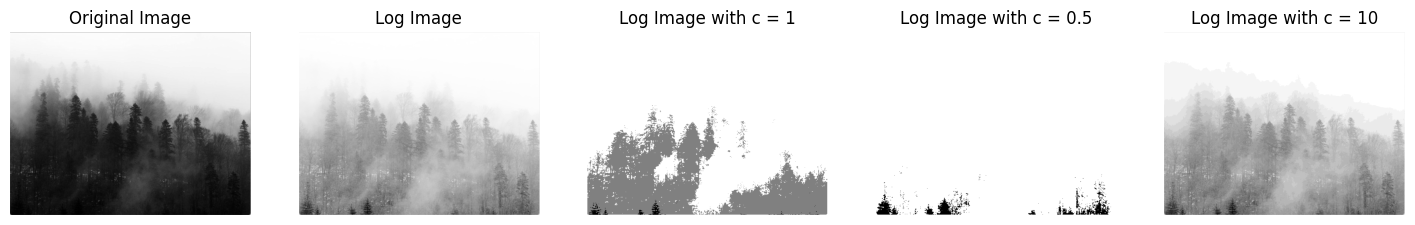

In [ ]:
log_image = log_transform_image(image=image.copy())
log_image_c1 = log_transform_image(image=image.copy(), c = 1, c_scaling = "Manually")
log_image_c_half = log_transform_image(image=image.copy(), c = 0.5, c_scaling = "Manually")
log_image_c10 = log_transform_image(image=image.copy(), c = 10, c_scaling = "Manually")

plt.figure(figsize=(18,5))

plt.subplot(1,5,1)
plt.imshow(image, cmap="gray")
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,5,2)
plt.imshow(log_image, cmap="gray")
plt.title('Log Image')
plt.axis('off')

plt.subplot(1,5,3)
plt.imshow(log_image_c1, cmap="gray")
plt.title('Log Image with c = 1')
plt.axis('off')

plt.subplot(1,5,4)
plt.imshow(log_image_c_half, cmap="gray")
plt.title('Log Image with c = 0.5')
plt.axis('off')

plt.subplot(1,5,5)
plt.imshow(log_image_c10, cmap="gray")
plt.title('Log Image with c = 10')
plt.axis('off')

plt.show()

### Effect of the Scaling Constant `c` in Logarithmic Transformation

The scaling constant `c` controls the overall brightness and contrast of the log-transformed image:

- **Default (c = outputMax / log(1+inputMax))**: Provides a balanced enhancement, making dark regions more visible while avoiding saturation in bright areas.
- **c = 1**: The image appears darker overall. Only the darker pixels are slightly enhanced, while many mid-tone and bright pixels are pushed closer to white.
- **c = 0.5**: Further reduces the effect, resulting in most of the image being almost black with very little detail visible in dark regions.
- **c = 10**: Increases brightness and contrast dramatically. Dark regions are enhanced strongly, revealing details that were invisible in the original image, but some areas may become saturated.

**Summary:** Larger values of `c` increase the intensity of enhancement, making darker areas more visible, while smaller values reduce the effect of the logarithmic mapping.
